# Smart Charging Using Reinforcement Learning

Approach for RL: an electric taxi is home from 2pm to 4pm each day. Every 15 minutes the charging agent picks a charging power (discrete levels between 0 and 22 kW). The battery can't exceed its capacity. When the taxi leaves at 4pm, a random energy demand for the day (D ~ N(30, 5) kWh) is drawn and must be covered by the battery, otherwise we pay a very high penalty. Charging cost grows with the square of the charging power. We model this as an MDP and solve it with Q-learning.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## MDP Definition

- State s = (t, b): the current 15-minute timestep $t \in \{0, ..., 7\}$ (2pm to 4pm)
  and the current battery level b, discretized into bins so we can use a Q-table.
- Action a: one of 4 discrete charging power levels (zero / low / medium / high).
- Transition: battery increases by power * 0.25h, capped at battery capacity.
- Reward: negative charging cost each step (cost = coef * power^2). At the final step, we additionally subtract a large penalty if the battery is below the sampled demand.

**Assumptions** (chosen by ourselves):
- Battery capacity: 50 kWh
- Charging levels: 0, 7, 14, 22 kW
- Starting battery level at 2pm: random between 5 and 20 kWh (car arrives partially depleted)
- Cost coefficient: 0.05 per kW²

In [35]:
# Environment settings
NUM_STEPS = 8                    # 15-min steps between 2pm and 4pm
STEP_HOURS = 0.25                # each step is 0.25 hours
BATTERY_CAPACITY = 50.0          # max kWh the battery can hold
CHARGE_LEVELS = [0, 7, 14, 22]   # kW, discrete actions (zero/low/medium/high)
BATTERY_BIN_SIZE = 1.0           # we round battery to 1 kWh bins for the Q-table

# cost = COST_COEFFS * power_kw**2 per step
# Time-varying cost coefficients (one per 15-min step, cheapest early)
COST_COEFFS = [0.02, 0.025, 0.03, 0.035, 0.04, 0.05, 0.06, 0.08]

DEMAND_MEAN = 30.0
DEMAND_STD = 5.0
OUT_OF_ENERGY_PENALTY = 1000.0

START_BATTERY_LOW = 5.0
START_BATTERY_HIGH = 20.0

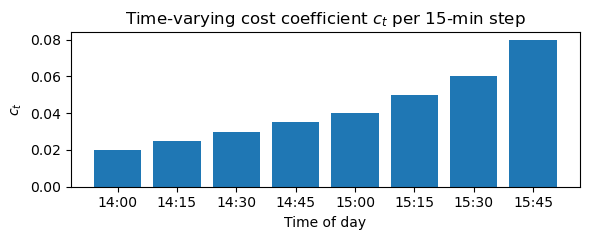

In [36]:
# Visualize the time-varying cost coefficients
step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS)]
plt.figure(figsize=(6, 2.5))
plt.bar(step_labels, COST_COEFFS)
plt.title("Time-varying cost coefficient $c_t$ per 15-min step")
plt.xlabel("Time of day")
plt.ylabel("$c_t$")
plt.tight_layout()
plt.show()

## Environment

In [37]:
# Simple discrete event simulation, following the same reset/step pattern used in the workshops

class SmartChargingEnv:
    # stores how many actions are we have
    def __init__(self):
        self.num_actions = len(CHARGE_LEVELS)

    # start of new episode: clock goes to 0 (= 2pm), battery is randomly set between 5 and 20 kWh
    # (simulating the car arriving partially depleted). Returns the initial state.
    def reset(self):
        self.t = 0
        self.battery = np.random.uniform(START_BATTERY_LOW, START_BATTERY_HIGH)
        return self._get_state()

    # discretization: the battery level gets rounded to an integer bin
    # the state tuple e.g. (3, 25) means timestep 3, battery at 25kWh (Q-table key)
    def _get_state(self):
        battery_bin = int(round(self.battery / BATTERY_BIN_SIZE))
        return (self.t, battery_bin)

    def step(self, action):
        # agent picks action index (0-3) and looks up corresponding kW
        # calculate how much energy that adds in 15min but cap battery to not exceed capacity
        # compute cost based on actual power used
        power = CHARGE_LEVELS[action]
        energy_added = min(power * STEP_HOURS, BATTERY_CAPACITY - self.battery)
        actual_power = energy_added / STEP_HOURS
        cost = COST_COEFFS[self.t] * actual_power ** 2

        # update battery and clock
        self.battery += energy_added
        self.t += 1
        done = self.t == NUM_STEPS

        # reward is negative since we want to minimize cost
        reward = -cost
        # at last step 4pm sample random energy demand
        # if battery can't cover it substract a huge penalty
        # teaches the agent to charge enough
        if done:
            demand = np.random.normal(DEMAND_MEAN, DEMAND_STD)
            if self.battery < demand:
                reward -= OUT_OF_ENERGY_PENALTY

        return self._get_state(), reward, done

In [38]:
# Sanity check: one random episode
env = SmartChargingEnv()
state = env.reset()
done = False
print("start state:", state)

while not done:
    action = np.random.randint(env.num_actions)
    state, reward, done = env.step(action)
    print(f"action={CHARGE_LEVELS[action]}kW -> state={state}, reward={reward:.2f}")

start state: (0, 6)
action=7kW -> state=(1, 8), reward=-0.98
action=7kW -> state=(2, 10), reward=-1.23
action=22kW -> state=(3, 15), reward=-14.52
action=22kW -> state=(4, 21), reward=-16.94
action=14kW -> state=(5, 24), reward=-7.84
action=0kW -> state=(6, 24), reward=-0.00
action=0kW -> state=(7, 24), reward=-0.00
action=22kW -> state=(8, 30), reward=-1038.72


## Q-Learning

In [39]:
# Same off-policy TD control update as in the workshop

# Hyperparameters
num_episodes = 20_000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9995

# Training
env = SmartChargingEnv()
Q = defaultdict(lambda: np.zeros(env.num_actions))
episode_rewards = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0.0

    # learning update
    while not done:
        if np.random.random() < epsilon:
            # explore
            action = np.random.randint(env.num_actions)
        else:
            # exploit
            action = np.argmax(Q[state])

        # take step
        next_state, reward, done = env.step(action)
        total_reward += reward

        # update q value
        best_next_value = np.max(Q[next_state])
        Q[state][action] += learning_rate * (reward + gamma * best_next_value - Q[state][action])
        state = next_state

    # after each episode shrink epsilon to increase exploitation and decrease exploration
    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training finished.")

Training finished.


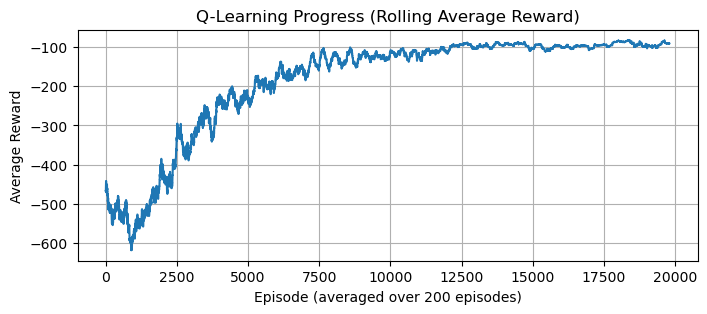

In [40]:
# Learning progress (rolling average reward)
window_size = 200
rolling_avg = np.convolve(episode_rewards, np.ones(window_size) / window_size, mode="valid")

plt.figure(figsize=(8, 3))
plt.plot(rolling_avg)
plt.title("Q-Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

## Evaluate learned policy

### Single greedy episode

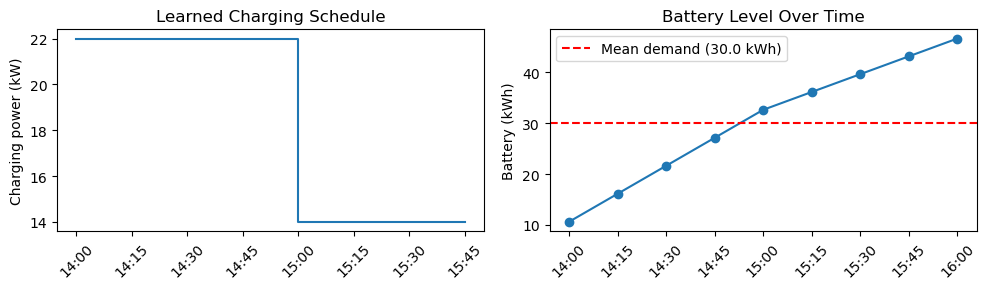

In [41]:
# Run one episode greedily (no exploration) and inspect the charging schedule and battery trajectory.
np.random.seed(42)
state = env.reset()
done = False
battery_trace = [env.battery]
power_trace = []

while not done:
    # greedy, no randomness
    # after training run one episode with pure expoitation
    action = np.argmax(Q[state])
    power_trace.append(CHARGE_LEVELS[action])
    state, reward, done = env.step(action)
    battery_trace.append(env.battery)

step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS + 1)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].step(range(NUM_STEPS), power_trace, where="post")
axes[0].set_xticks(range(NUM_STEPS))
axes[0].set_xticklabels(step_labels[:NUM_STEPS], rotation=45)
axes[0].set_title("Learned Charging Schedule")
axes[0].set_ylabel("Charging power (kW)")

axes[1].plot(range(NUM_STEPS + 1), battery_trace, marker="o")
axes[1].set_xticks(range(NUM_STEPS + 1))
axes[1].set_xticklabels(step_labels, rotation=45)
axes[1].axhline(DEMAND_MEAN, color="red", linestyle="--", label=f"Mean demand ({DEMAND_MEAN} kWh)")
axes[1].set_title("Battery Level Over Time")
axes[1].set_ylabel("Battery (kWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluation over many episodes

In [42]:
# Compared the learned policy against a naive baseline that always charges at maximum power
def evaluate_policy(env, policy_fn, n_episodes=2000):
    """Run n episodes with the given policy and collect costs + failure rate."""
    total_costs = []
    failures = 0

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        ep_cost = 0.0

        while not done:
            action = policy_fn(state)
            state, reward, done = env.step(action)
            ep_cost += -reward  # reward is negative cost (+ penalty)

        if ep_cost > 500:  # episode hit the out-of-energy penalty
            failures += 1
        total_costs.append(ep_cost)

    return total_costs, failures

In [43]:
# Learned policy: greedy from Q-table
def learned_policy(state):
    return np.argmax(Q[state])

# Baseline: always charge at max (action index 3 = 22 kW)
def baseline_max(state):
    return 3

In [44]:
env_eval = SmartChargingEnv()
n_eval = 2000

costs_learned, fails_learned = evaluate_policy(env_eval, learned_policy, n_eval)
costs_baseline, fails_baseline = evaluate_policy(env_eval, baseline_max, n_eval)

print("=== Learned Q-Learning Policy ===")
print(f"  Avg cost:          {np.mean(costs_learned):.2f}")
print(f"  Median cost:       {np.median(costs_learned):.2f}")
print(f"  Out-of-energy rate: {fails_learned / n_eval * 100:.1f}%")
print()
print("=== Baseline (always max charge) ===")
print(f"  Avg cost:          {np.mean(costs_baseline):.2f}")
print(f"  Median cost:       {np.median(costs_baseline):.2f}")
print(f"  Out-of-energy rate: {fails_baseline / n_eval * 100:.1f}%")

=== Learned Q-Learning Policy ===
  Avg cost:          92.70
  Median cost:       80.89
  Out-of-energy rate: 0.8%

=== Baseline (always max charge) ===
  Avg cost:          119.16
  Median cost:       118.23
  Out-of-energy rate: 0.0%


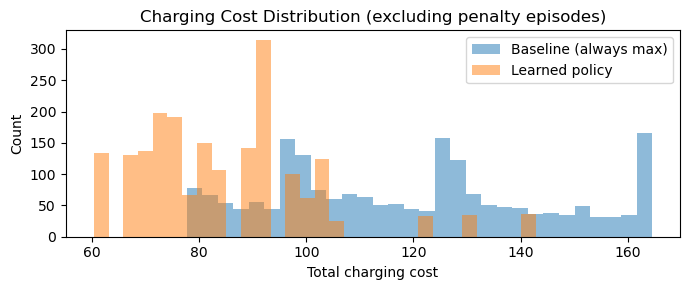

In [45]:
# Compare cost distributions (excluding penalty episodes for a cleaner view)
costs_learned_clean = [c for c in costs_learned if c < 500]
costs_baseline_clean = [c for c in costs_baseline if c < 500]

plt.figure(figsize=(7, 3))
plt.hist(costs_baseline_clean, bins=30, alpha=0.5, label="Baseline (always max)")
plt.hist(costs_learned_clean, bins=30, alpha=0.5, label="Learned policy")
plt.title("Charging Cost Distribution (excluding penalty episodes)")
plt.xlabel("Total charging cost")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Policy visualization

A heatmap showing which charging action the agent picks at each (timestep, battery, level) state. This is the optimal charging policy found by Q-Learning.

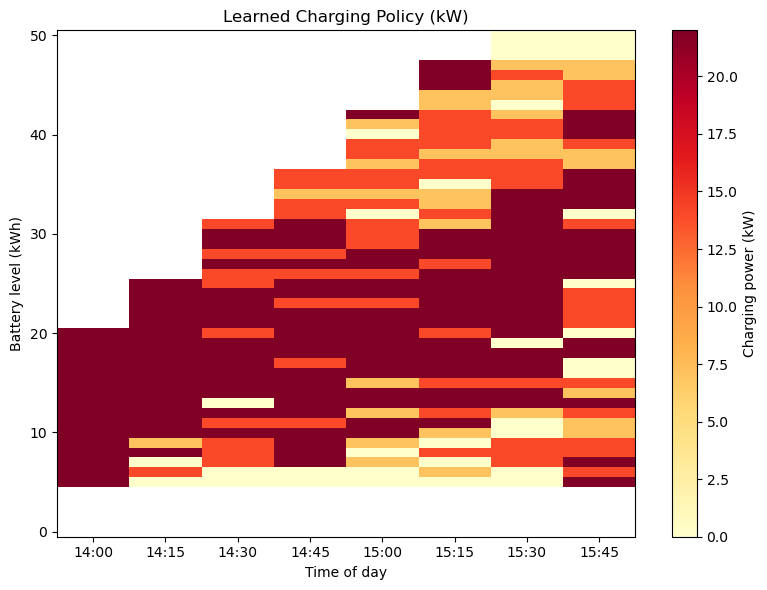

In [46]:
# Build a grid of the policy over all relevant states
max_battery_bin = int(BATTERY_CAPACITY / BATTERY_BIN_SIZE)
policy_grid = np.full((max_battery_bin + 1, NUM_STEPS), np.nan)

for t in range(NUM_STEPS):
    for b in range(max_battery_bin + 1):
        state = (t, b)
        if state in Q:
            policy_grid[b, t] = CHARGE_LEVELS[np.argmax(Q[state])]

step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS)]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(policy_grid, aspect="auto", origin="lower",
               cmap="YlOrRd", vmin=0, vmax=22)

ax.set_xticks(range(NUM_STEPS))
ax.set_xticklabels(step_labels)
ax.set_xlabel("Time of day")
ax.set_ylabel("Battery level (kWh)")
ax.set_title("Learned Charging Policy (kW)")
plt.colorbar(im, ax=ax, label="Charging power (kW)")
plt.tight_layout()
plt.show()

## Discussion

Key findings
- learned policy charges aggressively during the cheaper early time steps and reduces or stops charging later when the cost coefficient is higher, unlike the naive baseline which always charges at maximum regardlkess of price
- the agent reliably avoids the out-of-energy penalty by ensuring the battery is above approx. 30 kwh (the mean demand) before departure, while spending less on charging than the baseline